## **Business Problem**
- #### *Olist is an online marketplace that connects multiple sellers to customers across Brazil.*
- #### *However, the company faces challenges with delivery delays, which negatively affect customer satisfaction and review scores.*
- #### *Late deliveries reduce customer trust, increase churn, and can hurt Olist’s overall sales and brand reputation.*
- #### *The business wants to identify what factors are driving these delays and how much they impact customer satisfaction, so it can improve delivery performance and enhance the customer experience.*
---

## **Project Objective**
- #### *The main objective of this project is to analyze Olist’s e-commerce data to uncover the factors that lead to delivery delays and understand how these delays impact customer satisfaction and review scores.*
- #### *Based on the analysis, the goal is to recommend operational and strategic improvements that can help Olist reduce delivery delays, enhance customer satisfaction, and increase repeat purchases.*
---


## Data Loading, Cleaning and Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows",100)
pd.set_option("display.max_columns",100)

In [3]:
# importing our dataset
df=pd.read_csv(r"D:\dataset\olist\olist_complete.csv")
df.head()

,order_id,product_id,product_category_name_english,review_score,seller_id,seller_state,price,freight_value,order_status,customer_id,customer_zip_code_prefix,geo_lat,geo_long,customer_state,payment_type,payment_value,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,5f79b5b0931d63f1a42989eb65b9da6e,64315bd8c0c47303179dd2e25b579d00,toys\r,1,7aa4334be125fcdd2ba64b3180029f14,SP,89.80,24.94,delivered,00012a2ce6f8dcda20d059ce98491703,6273,-23.4993,-46.7676,SP,credit_card,114.74,21/11/2017 16:35,14/11/2017 16:08,14/11/2017 16:35,17/11/2017 15:32,28/11/2017 15:41,04/12/2017 00:00
1,0ab7fb08086d4af9141453c91878ed7a,868b3136c5b206f91b8208fbfdf2cb7c,bed_bath_table\r,4,4a3ca9315b744ce9f8e9374361493884,SP,93.00,14.01,delivered,000379cdec625522490c315e70c7a9fb,4841,-23.7405,-46.6901,SP,boleto,107.01,10/04/2018 03:10,02/04/2018 13:42,04/04/2018 03:10,04/04/2018 18:11,13/04/2018 20:21,18/04/2018 00:00
2,cd3558a10d854487b4f907e9b326a4fc,fa23bf270fb9880690b07d09b9f9ff20,sports_leisure\r,1,1b8356dabde1d35e17cef975c3f82730,SP,59.99,11.81,delivered,0004164d20a9e969af783496f3408652,13272,-22.9451,-46.9979,SP,voucher,71.80,18/04/2017 08:50,12/04/2017 08:35,12/04/2017 08:50,12/04/2017 17:05,20/04/2017 16:12,04/05/2017 00:00
3,263ba12390d0fbce329dd16da8cd20f8,c5fff00bf5f821911d676badbb286675,bed_bath_table\r,4,da8622b14eb17ae2831f4ac5b9dab84a,SP,134.90,12.43,delivered,0005aefbb696d34b3424dccd0a0e9fd0,3052,-23.5414,-46.6096,SP,credit_card,147.33,22/06/2018 10:21,20/06/2018 09:46,20/06/2018 10:21,21/06/2018 15:17,22/06/2018 17:58,03/07/2018 00:00
4,c208db5638f7f1cd04d185856852f864,ffbe3df3856b1fef3fee8f1264105a89,health_beauty\r,3,cbd996ad3c1b7dc71fd0e5f5df9087e2,SP,47.99,10.96,delivered,00062b33cb9f6fe976afdcff967ea74d,2306,-23.4415,-46.5941,SP,boleto,58.95,22/03/2017 23:44,15/03/2017 23:44,15/03/2017 23:44,17/03/2017 15:01,24/03/2017 14:59,04/04/2017 00:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117013 entries, 0 to 117012
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117013 non-null  object 
 1   product_id                     117013 non-null  object 
 2   product_category_name_english  117013 non-null  object 
 3   review_score                   117013 non-null  int64  
 4   seller_id                      117013 non-null  object 
 5   seller_state                   117013 non-null  object 
 6   price                          117013 non-null  float64
 7   freight_value                  117013 non-null  float64
 8   order_status                   117013 non-null  object 
 9   customer_id                    117013 non-null  object 
 10  customer_zip_code_prefix       117013 non-null  int64  
 11  geo_lat                        117013 non-null  float64
 12  geo_long                      

In [5]:
df.isnull().sum()

order_id                            0
product_id                          0
product_category_name_english       0
review_score                        0
seller_id                           0
seller_state                        0
price                               0
freight_value                       0
order_status                        0
customer_id                         0
customer_zip_code_prefix            0
geo_lat                             0
geo_long                            0
customer_state                      0
payment_type                        0
payment_value                       0
shipping_limit_date                 0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1228
order_delivered_customer_date    2457
order_estimated_delivery_date       0
dtype: int64

In [6]:
# cleaning "product_category_name_english" columns
df['product_category_name_english']=df['product_category_name_english'].apply(lambda x: x.replace("\r","") if "\r"in str(x) else x)
df['product_category_name_english']=df['product_category_name_english'].replace(r"\N","UNKNOWN")

In [7]:
# Removing blank spaces
for i in df.select_dtypes(include="object").columns:
    df[i]=df[i].str.strip()

In [8]:
# changing column's datatype having date/time into dateime datatype 
date_col=['shipping_limit_date',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date']
for i in date_col:
    df[i]=pd.to_datetime(df[i],format="%d/%m/%Y %H:%M",errors="coerce")

In [9]:
# sorting dataset according "Purchase Timestamp"
df=df.sort_values('order_purchase_timestamp')

In [10]:
# checking duplicates values and listing them together
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,order_id,product_id,product_category_name_english,review_score,seller_id,seller_state,price,freight_value,order_status,customer_id,customer_zip_code_prefix,geo_lat,geo_long,customer_state,payment_type,payment_value,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6323,0008288aa423d2a3f00fcb17cd7d8719,368c6c730842d78016ad823897a372db,garden_tools,5,1f50f920176fa81dab994f9023523100,SP,49.90,13.37,delivered,2355af7c75e7c98b43a87b2a7f210dc5,6600,-23.53250,-46.9034,SP,boleto,126.54,2018-02-21 02:55:00,2018-02-13 22:10:00,2018-02-15 03:55:00,2018-02-20 18:23:00,2018-02-26 13:55:00,2018-03-06
6324,0008288aa423d2a3f00fcb17cd7d8719,368c6c730842d78016ad823897a372db,garden_tools,5,1f50f920176fa81dab994f9023523100,SP,49.90,13.37,delivered,2355af7c75e7c98b43a87b2a7f210dc5,6600,-23.53250,-46.9034,SP,boleto,126.54,2018-02-21 02:55:00,2018-02-13 22:10:00,2018-02-15 03:55:00,2018-02-20 18:23:00,2018-02-26 13:55:00,2018-03-06
109386,001ab0a7578dd66cd4b0a71f5b6e1e41,0b0172eb0fd18479d29c3bc122c058c2,electronics,4,5656537e588803a555b8eb41f07a944b,DF,24.89,17.63,delivered,8bb3bef4e75a95524235cdc11a7331af,40055,-12.97140,-38.5019,BA,boleto,127.56,2018-01-04 02:33:00,2017-12-27 00:38:00,2017-12-28 02:33:00,2017-12-28 18:09:00,2018-01-17 20:43:00,2018-01-29
109388,001ab0a7578dd66cd4b0a71f5b6e1e41,0b0172eb0fd18479d29c3bc122c058c2,electronics,4,5656537e588803a555b8eb41f07a944b,DF,24.89,17.63,delivered,8bb3bef4e75a95524235cdc11a7331af,40055,-12.97140,-38.5019,BA,boleto,127.56,2018-01-04 02:33:00,2017-12-27 00:38:00,2017-12-28 02:33:00,2017-12-28 18:09:00,2018-01-17 20:43:00,2018-01-29
109387,001ab0a7578dd66cd4b0a71f5b6e1e41,0b0172eb0fd18479d29c3bc122c058c2,electronics,4,5656537e588803a555b8eb41f07a944b,DF,24.89,17.63,delivered,8bb3bef4e75a95524235cdc11a7331af,40055,-12.97140,-38.5019,BA,boleto,127.56,2018-01-04 02:33:00,2017-12-27 00:38:00,2017-12-28 02:33:00,2017-12-28 18:09:00,2018-01-17 20:43:00,2018-01-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107305,fff8287bbae429a99bb7e8c21d151c41,bee2e070c39f3dd2f6883a17a5f0da45,computers_accessories,5,4e922959ae960d389249c378d1c939f5,SP,180.00,48.14,delivered,6c1e92a209dbf868706caa831090941e,58075,-7.18250,-34.8715,PB,credit_card,456.28,2018-03-27 12:29:00,2018-03-17 12:11:00,2018-03-17 12:29:00,2018-03-21 19:22:00,2018-04-07 10:07:00,2018-04-19
87665,fffb9224b6fc7c43ebb0904318b10b5f,43423cdffde7fda63d0414ed38c11a73,watches_gifts,4,b1fc4f64df5a0e8b6913ab38803c57a9,RJ,55.00,34.19,delivered,4d3abb73ceb86353aeadbe698aa9d5cb,56912,-7.99572,-38.2944,PE,boleto,356.76,2017-11-03 02:55:00,2017-10-27 16:51:00,2017-10-28 02:55:00,2017-11-10 19:31:00,2017-11-17 19:41:00,2017-11-27
87662,fffb9224b6fc7c43ebb0904318b10b5f,43423cdffde7fda63d0414ed38c11a73,watches_gifts,4,b1fc4f64df5a0e8b6913ab38803c57a9,RJ,55.00,34.19,delivered,4d3abb73ceb86353aeadbe698aa9d5cb,56912,-7.99572,-38.2944,PE,boleto,356.76,2017-11-03 02:55:00,2017-10-27 16:51:00,2017-10-28 02:55:00,2017-11-10 19:31:00,2017-11-17 19:41:00,2017-11-27
87664,fffb9224b6fc7c43ebb0904318b10b5f,43423cdffde7fda63d0414ed38c11a73,watches_gifts,4,b1fc4f64df5a0e8b6913ab38803c57a9,RJ,55.00,34.19,delivered,4d3abb73ceb86353aeadbe698aa9d5cb,56912,-7.99572,-38.2944,PE,boleto,356.76,2017-11-03 02:55:00,2017-10-27 16:51:00,2017-10-28 02:55:00,2017-11-10 19:31:00,2017-11-17 19:41:00,2017-11-27


In [11]:
# deleting dulicates values
df.drop_duplicates(inplace=True)

In [12]:
# now, no duplicate values present in dataset
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,order_id,product_id,product_category_name_english,review_score,seller_id,seller_state,price,freight_value,order_status,customer_id,customer_zip_code_prefix,geo_lat,geo_long,customer_state,payment_type,payment_value,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [13]:
# deleting null values from columns 'order_approved_at','order_delivered_carrier_date','order_delivered_customer_date'
df.dropna(subset=['order_approved_at','order_delivered_carrier_date','order_delivered_customer_date'],inplace=True)

In [14]:
df.reset_index(drop=True,inplace=True)

## Features Engineering

In [15]:
# by how many days order got delay
df['delay_in_days']=(df['order_delivered_customer_date']-df['order_estimated_delivery_date']).dt.days


# Whether order got delayed or not 0 --> No delay and 1--> delayed
df['delayed']=df['delay_in_days'].apply(lambda x: 0 if x<=0 else 1)


# Creating payment range
bins = [0,100,200,300,400,500,600,50000]
labels = ['0-100', '100-200', '200-300', '300-400','400-500','500-600','more than 600']
df['payment_range'] = pd.cut(df['payment_value'], bins=bins, labels=labels, right=False)


# cutsomer type- First_time or Repeated 
customer_counts = df['customer_id'].value_counts()
df['customer_type'] = df['customer_id'].map(lambda x: 'Repeated' if customer_counts[x] > 1 else 'First-time')


# we create a column assuming that if order got delayed by 3 or more days
# and customer give review_score<=1 means our order got returned
# df['order_return']=df.apply(lambda x: 'yes' if (x['review_score']<=1 and x['delay_in_days']>=3) else 'no',axis=1)


# division of brazil states into five regions
North=['AC', 'AM', 'PA', 'RO', 'RR', 'TO']
North_east=['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
Central_West=['GO', 'MT', 'MS']
South_east=['ES', 'MG', 'RJ', 'SP']
South=['PR', 'RS', 'SC']
# assigning region of customers
df['cust_region']=df['customer_state'].apply(lambda x: 'North' if x in North
                                                 else 'North_east' if x in North_east
                                                 else 'Central_West' if x in Central_West
                                                 else 'South_east' if x in South_east
                                                 else 'South')


# days in which seller deliver the order to carrier
df['days_taken_seller_to_carrier']=(df['order_delivered_carrier_date']-df['order_approved_at']).dt.days


# estimated no. of days to deliver order to customer by carrier
df['estimated_days_for_delivery_by_carrier']=(df['order_estimated_delivery_date']-df['order_delivered_carrier_date']).dt.days


# actual no. of days taken by carrier for delivery
df['days_taken_by_carrier']=(df['order_delivered_customer_date']-df['order_delivered_carrier_date']).dt.days

In [16]:
# Re-arranging some columns
df=df[['order_id', 'product_id', 'product_category_name_english', 'review_score',
       'seller_id', 'seller_state', 'price', 'freight_value',
       'order_status', 'customer_id', 'customer_type', 'customer_zip_code_prefix',
       'geo_lat', 'geo_long', 'customer_state', 'cust_region', 'payment_type',
       'payment_value','payment_range', 'shipping_limit_date', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delayed', 'delay_in_days',
       'days_taken_seller_to_carrier','estimated_days_for_delivery_by_carrier', 'days_taken_by_carrier']]

## Final Cleaned Dataset

In [17]:
df.head()

,order_id,product_id,product_category_name_english,review_score,seller_id,seller_state,price,freight_value,order_status,customer_id,customer_type,customer_zip_code_prefix,geo_lat,geo_long,customer_state,cust_region,payment_type,payment_value,payment_range,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delayed,delay_in_days,days_taken_seller_to_carrier,estimated_days_for_delivery_by_carrier,days_taken_by_carrier
0,3b697a20d9e427646d92567910af6d57,3ae08df6bcbfe23586dd431c40bddbb7,watches_gifts,4,522620dcb18a6b31cd7bdf73665113a9,PR,29.90,15.56,delivered,355077684019f7f60a031656bd7262b8,First-time,4106,-23.5828,-46.6362,SP,South_east,boleto,45.46,0-100,2016-10-21 16:27:00,2016-10-03 09:44:00,2016-10-06 15:50:00,2016-10-23 14:02:00,2016-10-26 14:02:00,2016-10-27,0,-1,16,3,3
1,be5bc2f0da14d8071e2d45451ad119d9,fd7fd78fd3cbc1b0a6370a7909c0a629,sports_leisure,4,f09b760d23495ac9a7e00d29b769007c,SP,21.90,17.19,delivered,7ec40b22510fdbea1b08921dd39e63d8,First-time,98280,-28.2953,-53.4996,RS,South,boleto,39.09,0-100,2016-10-21 16:33:00,2016-10-03 16:56:00,2016-10-06 16:03:00,2016-10-21 16:33:00,2016-10-27 18:19:00,2016-11-07,0,-11,15,16,6
2,65d1e226dfaeb8cdc42f665422522d14,9c7bdf67b06b419aefb93cfdfc96c55d,sports_leisure,1,ed49da7cadefc454d6a67de249eab240,SP,21.50,14.11,canceled,70fc57eeae292675927697fe03ad3ff5,First-time,22770,-22.9409,-43.3568,RJ,South_east,credit_card,35.61,0-100,2016-10-21 16:24:00,2016-10-03 21:01:00,2016-10-04 10:18:00,2016-10-25 12:14:00,2016-11-08 10:58:00,2016-11-25,0,-17,21,30,13
3,a41c8759fbe7aab36ea07e038b2d4465,b72b39418216e944bb34e35f4d3ea8c7,sports_leisure,3,45d33f715e24d15a6ccf5c17b3a23e3c,SP,36.49,17.24,delivered,6f989332712d3222b6571b1cf5b835ce,First-time,90040,-30.0431,-51.2114,RS,South,boleto,53.73,0-100,2016-10-21 16:18:00,2016-10-03 21:13:00,2016-10-05 03:11:00,2016-10-25 11:57:00,2016-11-03 10:58:00,2016-11-29,0,-26,20,34,8
4,d207cc272675637bfed0062edffd0818,107177bf61755f05c604fe57e02467d6,furniture_decor,1,cca3071e3e9bb7d12640c9fbe2301306,SP,119.90,13.56,delivered,b8cf418e97ae795672d326288dfab7a7,First-time,13185,-22.9044,-47.1755,SP,South_east,credit_card,133.46,100-200,2016-10-21 16:23:00,2016-10-03 22:06:00,2016-10-04 10:28:00,2016-10-21 14:23:00,2016-10-31 11:07:00,2016-11-23,0,-23,17,32,9


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103272 entries, 0 to 103271
Data columns (total 30 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   order_id                                103272 non-null  object        
 1   product_id                              103272 non-null  object        
 2   product_category_name_english           103272 non-null  object        
 3   review_score                            103272 non-null  int64         
 4   seller_id                               103272 non-null  object        
 5   seller_state                            103272 non-null  object        
 6   price                                   103272 non-null  float64       
 7   freight_value                           103272 non-null  float64       
 8   order_status                            103272 non-null  object        
 9   customer_id                          

In [19]:
df.select_dtypes(include=('int64','float64')).describe()

,review_score,price,freight_value,customer_zip_code_prefix,geo_lat,geo_long,payment_value,delayed,delay_in_days,days_taken_seller_to_carrier,estimated_days_for_delivery_by_carrier,days_taken_by_carrier
count,103272.000000,103272.000000,103272.000000,103272.000000,103272.000000,103272.000000,103272.000000,103272.000000,103272.000000,103272.00000,103272.000000,103272.000000
mean,4.122376,123.481921,20.079922,35017.687737,-21.211149,-46.186390,157.123751,0.065003,-12.036196,2.28790,20.239271,8.798561
std,1.312504,186.870574,15.780211,29790.158845,5.592381,4.060552,216.258363,0.246533,10.156465,3.52045,8.767461,8.667858
min,1.000000,0.850000,0.000000,1003.000000,-36.605400,-72.666700,0.000000,0.000000,-147.000000,-172.00000,-100.000000,-17.000000
25%,4.000000,40.000000,13.130000,11310.000000,-23.588800,-48.106200,58.170000,0.000000,-17.000000,0.00000,15.000000,4.000000
50%,5.000000,78.000000,16.330000,24342.000000,-22.924500,-46.632000,102.740000,0.000000,-13.000000,1.00000,20.000000,7.000000
75%,5.000000,138.500000,21.190000,58298.000000,-20.155100,-43.615300,176.090000,0.000000,-7.000000,3.00000,25.000000,11.000000
max,5.000000,6735.000000,409.680000,99980.000000,42.184000,-8.577860,13664.100000,1.000000,188.000000,125.00000,192.000000,205.000000


## Exploratory Data Analysis

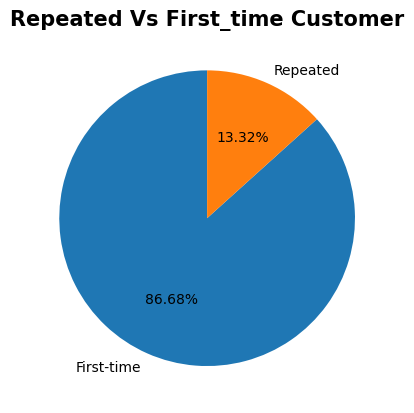

In [20]:
plt.title("Repeated Vs First_time Customer",fontdict={'fontsize':15,'fontweight':600})
plt.pie(df['customer_type'].value_counts(),normalize=True,startangle=90,
        labels=['First-time','Repeated'],autopct='%1.2f%%')
plt.show()

► Around 86.7% of customers are first-time buyers, showing Olist heavily depends on new customer acquisition.<br>► Only 13.3% are repeat customers, indicating limited customer loyalty and retention challenges.<br>► Enhancing post-purchase experience and delivery reliability could help convert more first-time buyers into repeat ones.

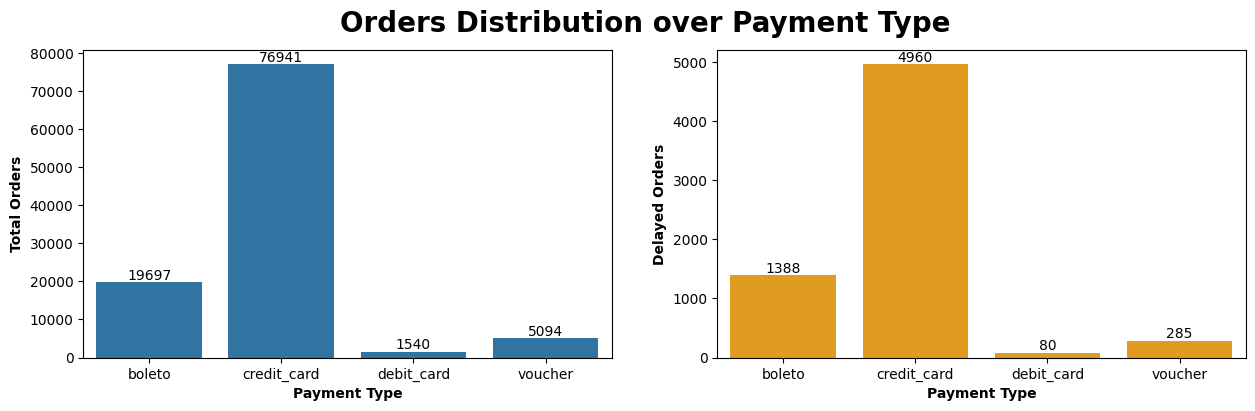

In [21]:
payment_dist=df.groupby(['payment_type']).agg(Total_orders=('order_id','count'),
                                              Delayed_orders=('delayed','sum')).reset_index()

plt.figure(figsize=(15,4))
plt.suptitle("Orders Distribution over Payment Type",fontsize=20,fontweight=700)

plt.subplot(1,2,1)
ax=sns.barplot(payment_dist,x='payment_type',y='Total_orders')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Payment Type",fontdict={'fontsize':10,'fontweight':600})
plt.ylabel("Total Orders",fontdict={'fontsize':10,'fontweight':600})

plt.subplot(1,2,2)
ax=sns.barplot(payment_dist,x='payment_type',y='Delayed_orders',color='orange')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Payment Type",fontdict={'fontsize':10,'fontweight':600})
plt.ylabel("Delayed Orders",fontdict={'fontsize':10,'fontweight':600})
plt.show()

► Most orders use credit cards (∼76K), followed by boleto (∼20K), showing strong customer preference for credit-based payments.<br>► Credit cards also have the most delays (∼5K), while debit cards show the fewest (80), suggesting faster processing.<br>► Despite fewer orders, methods like boleto/voucher show relatively higher delay proportions, likely due to slower payment confirmation processes.

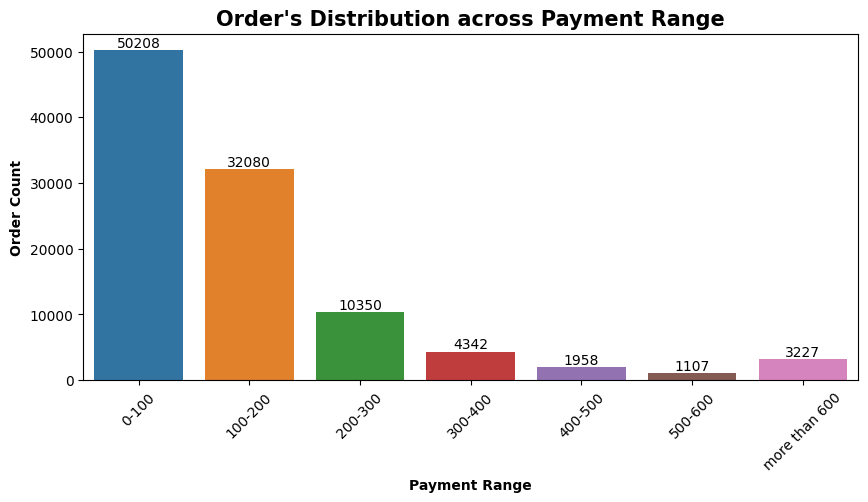

In [22]:
pay_range=df.groupby(['payment_range']).agg(order_count=('order_id','count')).reset_index()

plt.figure(figsize=(10,4.5))
plt.title("Order's Distribution across Payment Range",fontdict={'fontsize':15,'fontweight':700})
ax=sns.barplot(pay_range,x='payment_range',y='order_count',hue='payment_range')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Payment Range",fontdict={'fontsize':10,'fontweight':600})
plt.ylabel("Order Count",fontdict={'fontsize':10,'fontweight':600})
plt.xticks(rotation=45)
plt.show()

► Majority of orders (∼82%) fall under 200 BRL, showing a price-sensitive customer base.<br>► Very few orders exceed 400 BRL, suggesting that high-value transactions are rare.<br>► This indicates Olist’s core business relies on low-ticket, high-volume transactions.

In [23]:
# let assume carrier requires atleast 3 days for successful delivery
# if Carrier got delivery after estimated delivrey to customer or 
# less than 3 days before estimated delivery date to customer
# then Seller will be responsible for the delay.
# else Carrier will be responsible for the delay.

responsible=df.apply(lambda x: 'Seller' if (x['delayed']==1 and ((x['order_delivered_carrier_date']>x['order_estimated_delivery_date']) or 
                                                                      (x['order_estimated_delivery_date']-x['order_delivered_carrier_date']).days<3))
                             else 'Carrier' if (x['delayed']==1 and x['order_delivered_carrier_date']<x['order_estimated_delivery_date'])
                             else 'no_delay',axis=1)
responsible.value_counts()

no_delay    96559
Carrier      6003
Seller        710
Name: count, dtype: int64

In [24]:
Early_or_on_time=df['delayed'].loc[df['delayed']==0].shape[0]
Delayed=df['delayed'].loc[df['delayed']==1].shape[0]

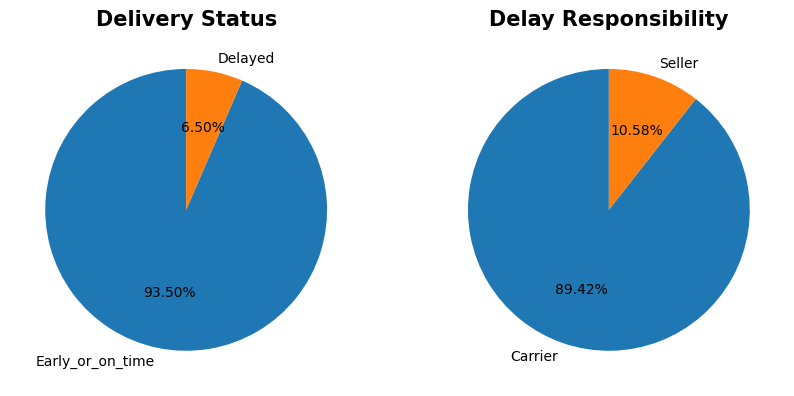

In [25]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Delivery Status",fontdict={'fontsize':15,'fontweight':600})
plt.pie([Early_or_on_time,Delayed],normalize=True,startangle=90,
        labels=['Early_or_on_time','Delayed'],autopct='%1.2f%%',)

plt.subplot(1,2,2)
plt.title("Delay Responsibility",fontdict={'fontsize':15,'fontweight':600})
plt.pie(responsible.value_counts()[1:],normalize=True,startangle=90,
        labels=['Carrier','Seller'],autopct='%1.2f%%',)
plt.show()

► 93.5% of deliveries are on-time, but the 6.5% delays still significantly impact satisfaction.<br>► Carriers cause 89% of delays, highlighting logistical inefficiencies as the main bottleneck.<br>► Improving courier partnerships or monitoring carrier SLAs could drastically enhance delivery performance.

In [26]:
monthly_orders=df.groupby(df['order_approved_at'].dt.month_name()
                          ).agg(total_order=("order_id","count"),
                                total_delays=("delayed","sum"),
                               total_sales=('payment_value','sum'),
                               ave_sales=('payment_value','mean')).reset_index()

monthly_orders.rename(columns={'order_approved_at':"Month_name"},inplace=True)
monthly_orders=monthly_orders.iloc[[4,3,7,0,8,6,5,1,11,10,9,2]]
monthly_orders.reset_index(drop=True,inplace=True)
monthly_orders

,Month_name,total_order,total_delays,total_sales,ave_sales
0,January,8285,430,1259370.27,152.006068
1,February,8637,957,1277999.39,147.967974
2,March,10273,1500,1600537.77,155.800425
3,April,9541,468,1574368.59,165.010857
4,May,11270,587,1828766.48,162.268543
5,June,9920,176,1594801.39,160.766269
6,July,10597,302,1643393.25,155.080990
7,August,11447,540,1768019.20,154.452625
8,September,4471,192,720157.76,161.073084
9,October,5101,182,847078.25,166.061213


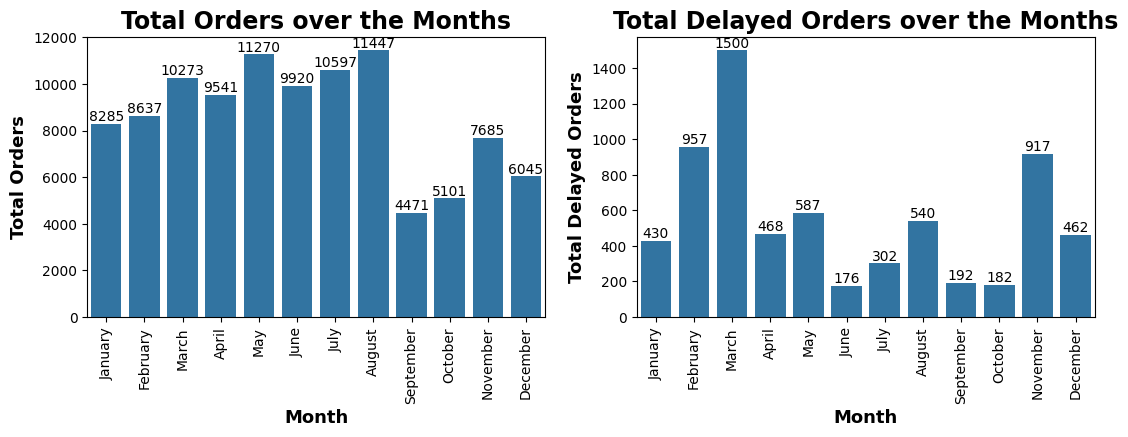

In [27]:
plt.figure(figsize=(13,8))
plt.subplot(2,2,1)
plt.title("Total Orders over the Months",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=monthly_orders,x='Month_name',y='total_order')
ax.bar_label(ax.containers[0])
plt.xlabel("Month",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Orders",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)

plt.subplot(2,2,2)
plt.title("Total Delayed Orders over the Months",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=monthly_orders,x='Month_name',y='total_delays')
ax.bar_label(ax.containers[0])
plt.xlabel("Month",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Delayed Orders",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)
plt.show()

► Orders peaked between May and August, indicating strong mid-year demand.<br>► Delays were highest in February–March, suggesting early-year operational bottlenecks.<br>► Despite lower orders in later months, delay spikes in November hint at delivery pressure during festive or promotional periods.

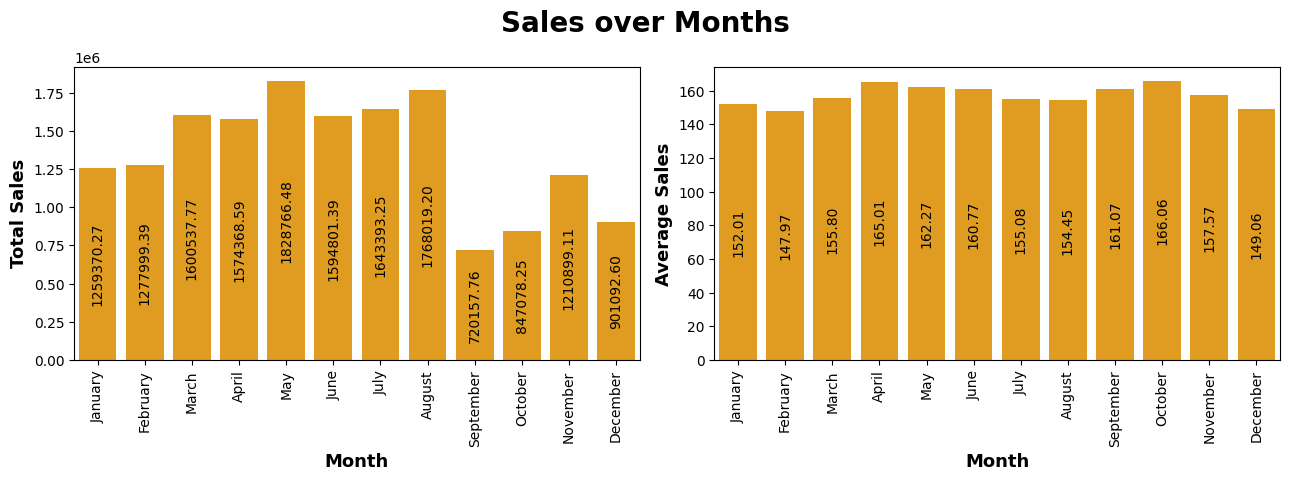

In [28]:
plt.figure(figsize=(13,8))

plt.suptitle("Sales over Months",fontsize=20,fontweight=600)

plt.subplot(2,2,1)
ax=sns.barplot(data=monthly_orders,x='Month_name',y='total_sales',color='orange')
for container in ax.containers:
    ax.bar_label(container,label_type='center',rotation=90,fmt='%0.2f')
plt.xlabel("Month",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Sales",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)

plt.subplot(2,2,2)
ax=sns.barplot(data=monthly_orders,x='Month_name',y='ave_sales',color='orange')
for container in ax.containers:
    ax.bar_label(container,label_type='center',rotation=90,fmt='%0.2f')
plt.xlabel("Month",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Average Sales",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

► Total sales peaked in May and August, aligning with high order volumes.<br>► Average sales per order remained relatively stable (~150–165 BRL), showing consistent pricing patterns.<br>► The sharp drop in total sales during September–October signals potential seasonal slowdown or post-peak fatigue.

In [29]:
Day_orders=df.groupby(df['order_approved_at'].dt.day_name()
                          ).agg(total_order=("order_id","count"),
                                total_delay=("delayed","sum"),
                                total_sales=('payment_value','sum'),
                                ave_sales=('payment_value','mean')).reset_index()

Day_orders.rename(columns={'order_approved_at':"Day_name"},inplace=True)
Day_orders=Day_orders.iloc[[1,5,6,4,0,2,3]]
Day_orders

,Day_name,total_order,total_delay,total_sales,ave_sales
1,Monday,13611,947,2167714.29,159.261942
5,Tuesday,19880,1298,3086396.53,155.251335
6,Wednesday,16347,1066,2553626.02,156.213741
4,Thursday,16061,944,2534645.94,157.813706
0,Friday,15266,1080,2392968.72,156.751521
2,Saturday,12717,798,2032783.34,159.847711
3,Sunday,9390,580,1458349.22,155.308756


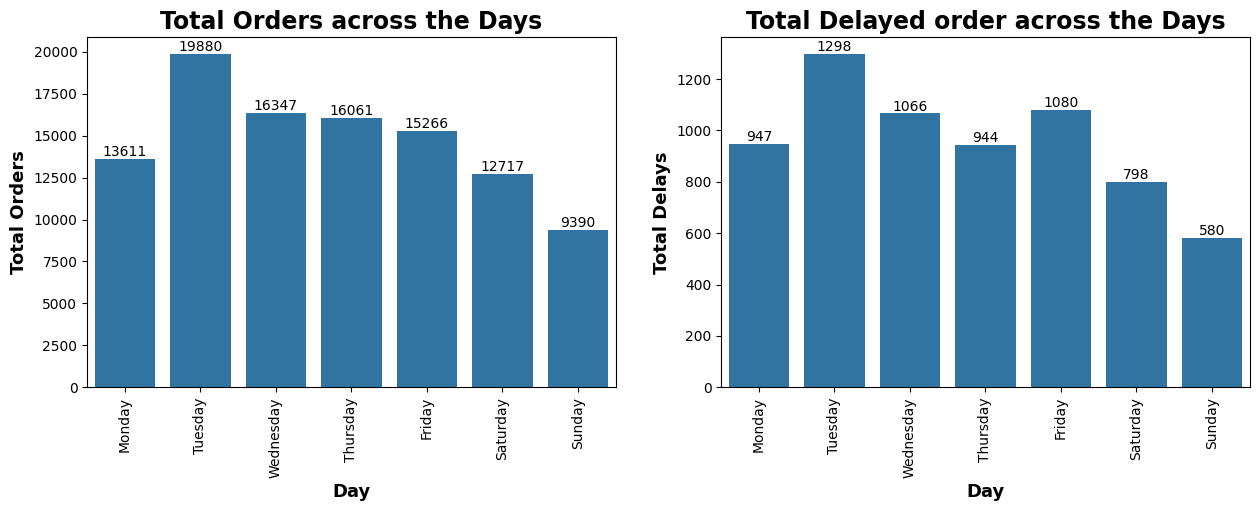

In [30]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.title("Total Orders across the Days",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=Day_orders,x='Day_name',y='total_order')
ax.bar_label(ax.containers[0])
plt.xlabel("Day",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Orders",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)


plt.subplot(2,2,2)
plt.title("Total Delayed order across the Days",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=Day_orders,x='Day_name',y='total_delay')
ax.bar_label(ax.containers[0])
plt.xlabel("Day",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Delays",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)
plt.show()

► Tuesday records the highest order volume and delay count, suggesting possible midweek operational overload.<br>► Delays remain moderate on weekends, correlating with fewer orders.<br>► This indicates capacity and logistics optimization is most needed early in the week.

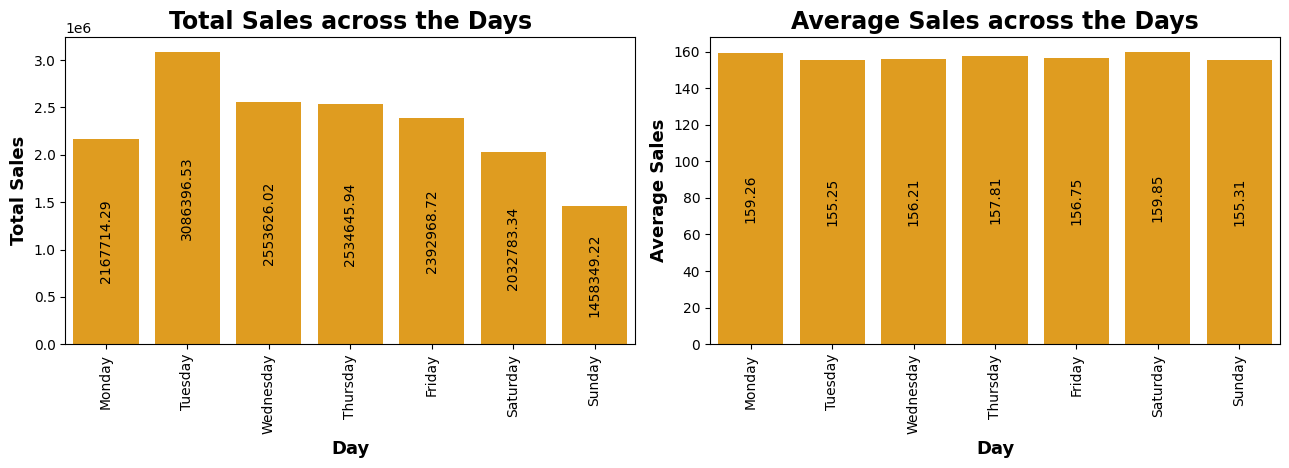

In [31]:
plt.figure(figsize=(13,8))
plt.subplot(2,2,1)
plt.title("Total Sales across the Days",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=Day_orders,x='Day_name',y='total_sales',color='orange')
for container in ax.containers:
    ax.bar_label(container,label_type='center',rotation=90,fmt='%0.2f')
plt.xlabel("Day",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Total Sales",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)

plt.subplot(2,2,2)
plt.title("Average Sales across the Days",fontdict={'fontsize':17,'fontweight':600})
ax=sns.barplot(data=Day_orders,x='Day_name',y='ave_sales',color='orange')
for container in ax.containers:
    ax.bar_label(container,label_type='center',rotation=90,fmt='%0.2f')
plt.xlabel("Day",fontdict={'fontsize':13,'fontweight':560})
plt.ylabel("Average Sales",fontdict={'fontsize':13,'fontweight':560})
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

► Tuesday drives the highest total sales (∼3M BRL), matching its order volume peak.<br>► Average sales remain consistent across days (∼155–160 BRL), implying stable per-order value.<br>► Sunday shows the lowest sales and order count, representing a natural weekly demand dip.

In [32]:
# orders across the hours and Days
total_order=pd.pivot_table(data=df,index=df['order_approved_at'].dt.hour,
               columns=df['order_approved_at'].dt.day_name(),values='order_id',aggfunc='count')
total_order

order_approved_at,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
order_approved_at,,,,,,,
0,337,261,261,250,323,314,334
1,305,155,313,188,247,177,205
2,1708,73,1775,100,1632,194,1632
3,803,30,724,35,992,1948,1005
4,295,22,301,25,298,2133,302
5,100,13,104,21,155,604,56
6,86,69,112,52,116,304,201
7,284,133,93,75,229,511,201
8,404,317,184,131,415,486,410


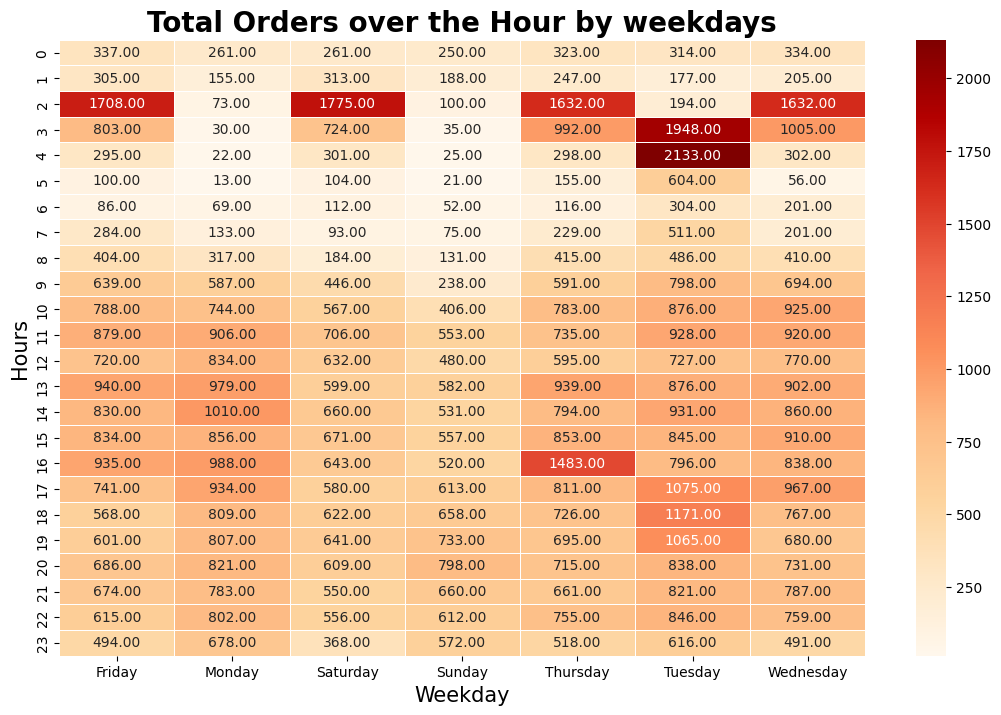

In [33]:
plt.figure(figsize=(13,8))
plt.title("Total Orders over the Hour by weekdays",fontdict={'fontsize':20,'fontweight':560})
sns.heatmap(data=total_order,annot=True,fmt='.2f',cmap="OrRd",linecolor='white',linewidths=0.5)
plt.xlabel("Weekday",fontsize=15)
plt.ylabel("Hours",fontsize=15)
plt.show()

► Peak order activity occurs between 2 AM–3 AM and 3 PM–6 PM, suggesting both early-night and afternoon surges.<br>► Tuesday and Thursday record the heaviest hourly order volumes, likely due to weekday promotions or workday convenience.<br>► Orders are relatively low during early morning and late-night hours, aligning with typical consumer shopping patterns.

In [34]:
avg_sale=pd.pivot_table(data=df,index=df['order_approved_at'].dt.hour,
               columns=df['order_approved_at'].dt.day_name(),values='payment_value',aggfunc='mean')
avg_sale

order_approved_at,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
order_approved_at,,,,,,,
0,155.306172,144.075287,146.602950,142.202440,136.602724,133.148248,164.229611
1,161.032885,141.979935,139.103642,149.399574,147.231336,143.759831,160.776780
2,145.535504,140.097808,143.395031,223.594100,153.821324,160.187010,156.639559
3,136.046762,154.369667,135.075483,133.987429,142.044687,141.983557,140.630408
4,155.752000,134.943636,142.875781,195.637600,175.535034,139.348758,140.376291
5,133.605400,144.831538,156.935962,138.173333,126.539548,135.645977,121.841786
6,178.273953,184.176812,187.623393,171.242308,165.068276,172.695230,190.083035
7,157.200775,181.875789,169.450323,158.409467,149.016288,172.777671,177.727512
8,169.096411,202.070978,191.171196,144.821298,166.429205,140.698210,164.314024


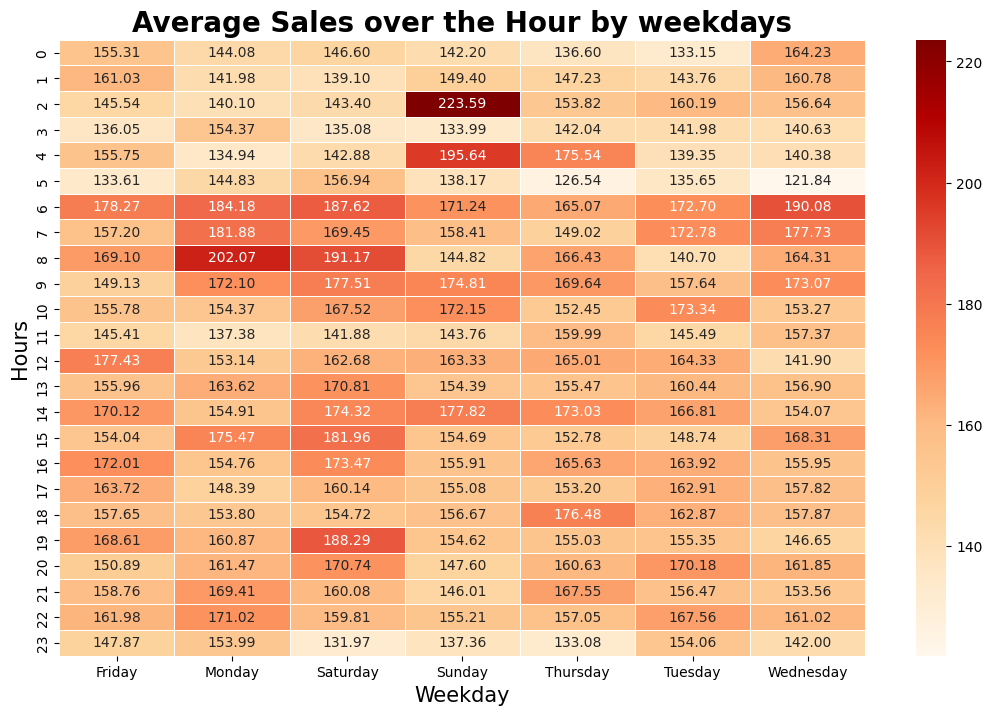

In [35]:
plt.figure(figsize=(13,8))
plt.title("Average Sales over the Hour by weekdays",fontdict={'fontsize':20,'fontweight':560})
sns.heatmap(data=avg_sale,annot=True,fmt='.2f',cmap="OrRd",linecolor='white',linewidths=0.5)
plt.xlabel("Weekday",fontsize=15)
plt.ylabel("Hours",fontsize=15)
plt.show()

► The highest average sales occur around 2–3 AM on Sundays, indicating that late-night buyers tend to make higher-value purchases.<br>► Consistent mid-day (8 AM–4 PM) spending across weekdays suggests stable daytime demand.<br>► Late-night hours still show moderate sales, showing Olist attracts active buyers beyond typical retail hours.

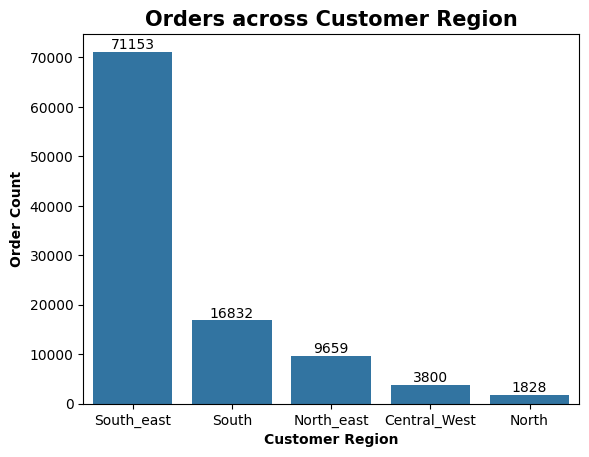

In [36]:
plt.title("Orders across Customer Region",fontdict={'fontsize':15,'fontweight':700})
ax=sns.barplot(data=df['cust_region'].value_counts())
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Customer Region",fontdict={'fontsize':10,'fontweight':600})
plt.ylabel("Order Count",fontdict={'fontsize':10,'fontweight':600})
plt.show()

► The South-East region dominates with over 70,000 orders, making it Olist’s primary market hub.<br>► Southern and North-Eastern regions contribute moderately, while Central-West and North show limited penetration.<br>► Expanding logistics and marketing in underperforming regions could diversify Olist’s customer base.

In [37]:
State_delay_sumry=df.groupby(['seller_state']).agg(delayed_order=('delayed','sum'),
                                   total_order=('delayed','count')).reset_index()
State_delay_sumry['delay%']=round((State_delay_sumry['delayed_order']/State_delay_sumry['total_order'])*100,2)
State_delay_sumry

,seller_state,delayed_order,total_order,delay%
0,AM,1,3,33.33
1,BA,28,578,4.84
2,CE,7,91,7.69
3,DF,45,843,5.34
4,ES,20,324,6.17
5,GO,13,489,2.66
6,MA,72,392,18.37
7,MG,375,8225,4.56
8,MS,2,48,4.17
9,MT,5,141,3.55


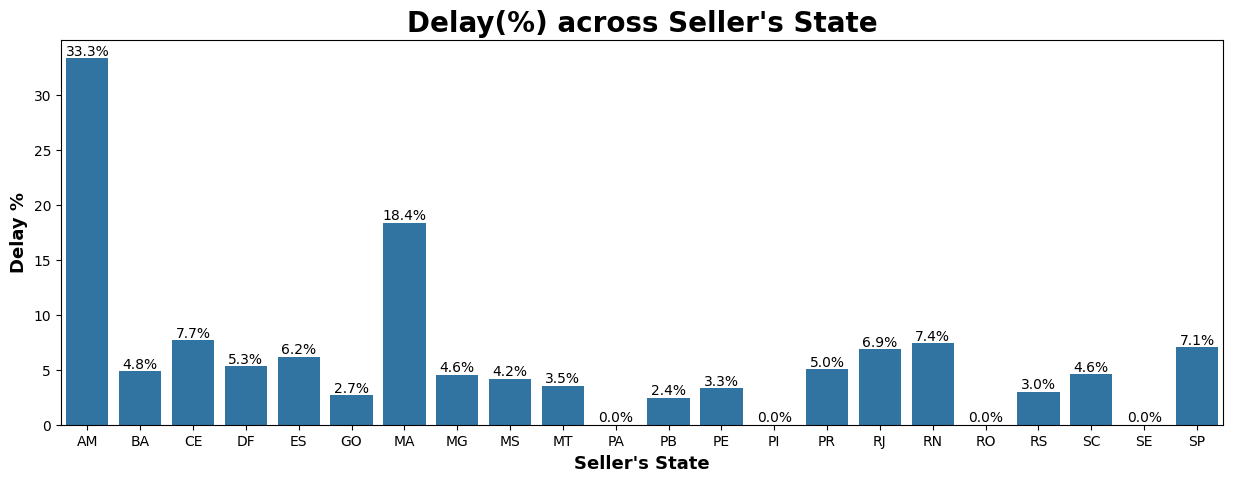

In [38]:
plt.figure(figsize=(15,5))
plt.title("Delay(%) across Seller's State",fontdict={'fontsize':20,'fontweight':700})
ax=sns.barplot(data=State_delay_sumry,x='seller_state',y='delay%')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.xlabel("Seller's State",fontdict={'fontsize':13,'fontweight':600})
plt.ylabel("Delay %",fontdict={'fontsize':13,'fontweight':600})
plt.show()

► Amazonas (AM) and Maranhão (MA) show extremely high delay rates (33% and 18%, respectively), indicating serious logistical challenges.<br>► Most major states like São Paulo (SP) and Rio de Janeiro (RJ) maintain moderate delay levels (~7%), reflecting stronger infrastructure.<br>► Targeted interventions in high-delay states could substantially improve overall delivery performance.

In [39]:
reg_delay=pd.pivot_table(data=df,index='cust_region',columns='seller_state',values='delayed',aggfunc='sum',fill_value=0)
reg_delay

seller_state,AM,BA,CE,DF,ES,GO,MA,MG,MS,MT,PA,PB,PE,PI,PR,RJ,RN,RO,RS,SC,SE,SP
cust_region,,,,,,,,,,,,,,,,,,,,,,
Central_West,0,0,0,2,0,0,6,11,0,0,0,0,0,0,8,11,0,0,1,7,0,211
North,0,2,2,1,1,0,1,9,0,0,0,0,0,0,8,5,0,0,1,2,0,120
North_east,1,15,3,14,0,3,17,74,1,3,0,0,5,0,69,49,2,0,16,26,0,897
South,0,2,0,9,3,5,11,39,0,0,0,0,5,0,68,53,2,0,15,31,0,704
South_east,0,9,2,19,16,5,37,242,1,2,0,1,4,0,246,183,0,0,28,109,0,3258


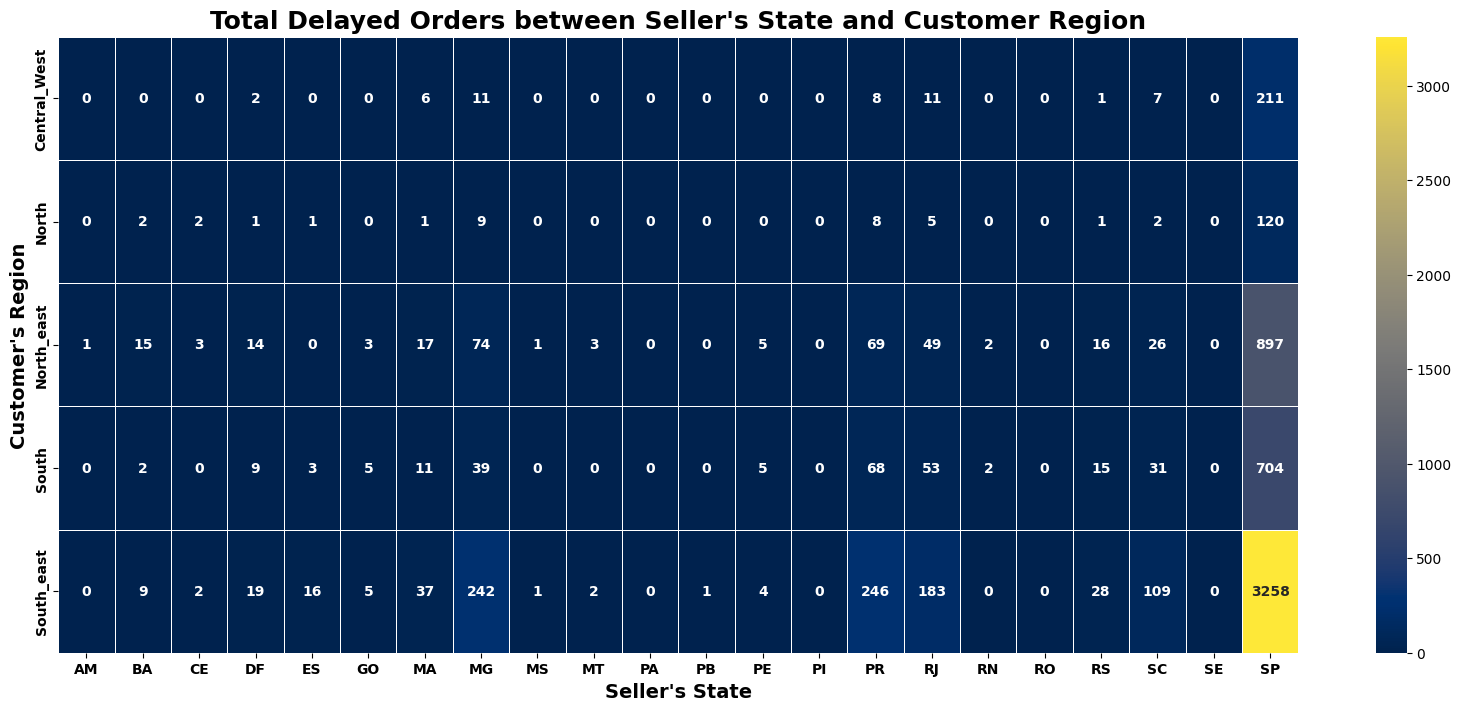

In [40]:
plt.figure(figsize=(20,8))
plt.title("Total Delayed Orders between Seller's State and Customer Region",
          fontdict={'fontsize':18,'fontweight':700})
sns.heatmap(data=reg_delay,annot=True,fmt='.0f',cmap="cividis",linecolor='white',
            linewidths=0.5,annot_kws={"weight": "bold"})
plt.xlabel("Seller's State",fontdict={'fontsize':14,'fontweight':600})
plt.xticks(fontweight=600)
plt.ylabel("Customer's Region",fontdict={'fontsize':14,'fontweight':600})
plt.yticks(fontweight=600)
plt.show()

► The highest delays occur between São Paulo (SP) sellers and South-East customers (∼ 3,258 delays), showing congestion within the busiest region.<br>► Noticeable but smaller clusters appear between Minas Gerais (MG) sellers and nearby regions, indicating localized bottlenecks.<br>► These patterns suggest that intra-regional logistics inefficiencies, not just long-distance shipping, are a key source of delays.

In [41]:
prod_cat=df.groupby(['product_category_name_english']).agg(total_order=('order_id','count'),
                                                           total_delays=('delayed','sum'),
                                                         ave_rating=('review_score','mean'),
                                                         total_sales=('payment_value','sum'),
                                                         ave_price=('price','mean')).reset_index()
prod_cat

,product_category_name_english,total_order,total_delays,ave_rating,total_sales,ave_price
0,UNKNOWN,1470,104,3.997959,208711.33,117.826796
1,agro_industry_and_commerce,204,7,4.215686,76646.17,339.886225
2,air_conditioning,247,9,4.121457,59665.07,181.449757
3,art,203,12,4.088670,27852.10,117.491379
4,arts_and_craftmanship,24,1,4.125000,2326.17,75.583750
5,audio,359,41,3.841226,57614.19,142.661448
6,auto,3996,281,4.124374,690611.13,140.684862
7,baby,2933,230,4.095465,487225.46,138.414501
8,bed_bath_table,10499,727,3.933613,1425203.38,94.352270
9,books_general_interest,520,35,4.503846,56325.33,85.448192


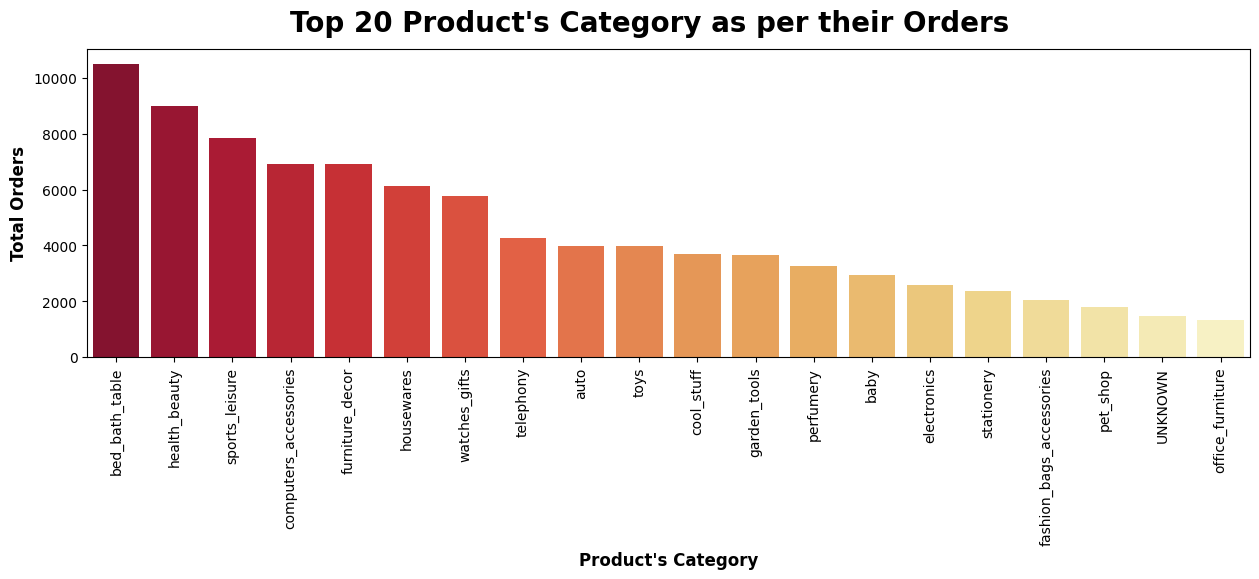

In [42]:
plt.figure(figsize=(15,4))
plt.suptitle("Top 20 Product's Category as per their Orders",fontsize=20,fontweight=750)
plt.subplot(1,1,1)
sns.barplot(data=prod_cat.sort_values('total_order',ascending=False).head(20),x='product_category_name_english',
            y='total_order',palette='YlOrRd_r')
plt.xlabel("Product's Category",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Total Orders",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)
plt.show()

► “Bed, Bath & Table” leads with the most orders, followed by Health & Beauty and Sports & Leisure, reflecting strong household and personal-care demand.<br>► Product mix is dominated by lifestyle and home categories rather than high-tech or luxury goods.<br>► Focusing on supply-chain efficiency for these top categories could yield the biggest impact on customer satisfaction.

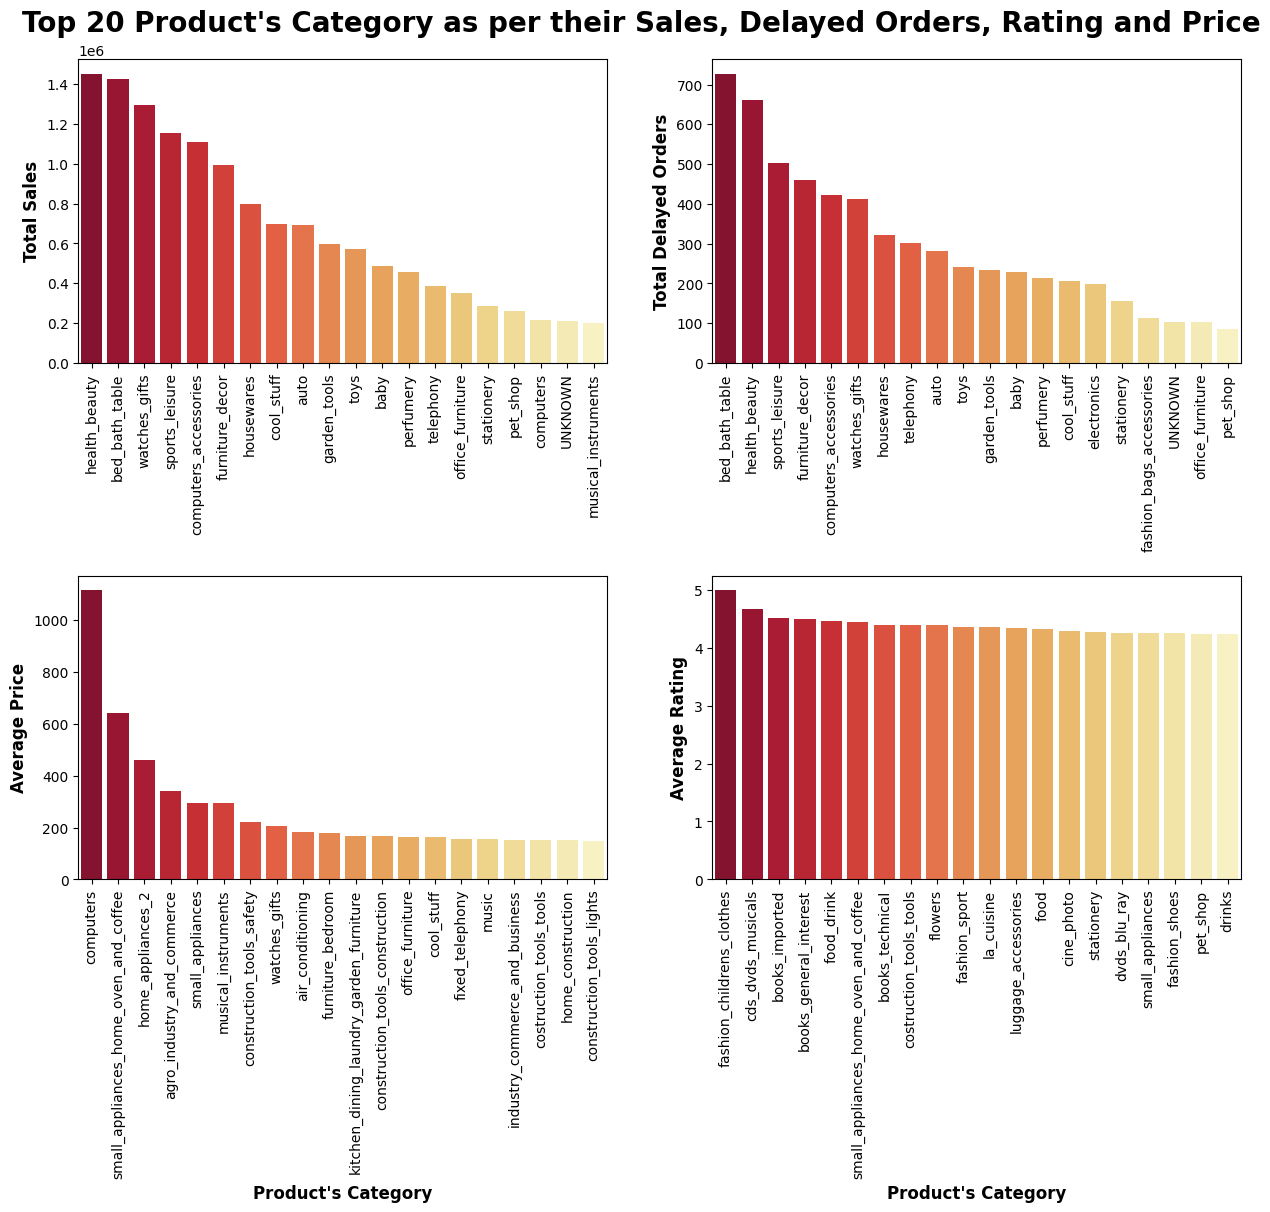

In [43]:
plt.figure(figsize=(15,10))
plt.suptitle("Top 20 Product's Category as per their Sales, Delayed Orders, Rating and Price",fontsize=20,fontweight=750)

plt.subplot(2,2,1)
sns.barplot(data=prod_cat.sort_values('total_sales',ascending=False).head(20),x='product_category_name_english',
            y='total_sales',palette='YlOrRd_r')
plt.xlabel("",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Total Sales",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)

plt.subplot(2,2,2)
sns.barplot(data=prod_cat.sort_values('total_delays',ascending=False).head(20),x='product_category_name_english',
            y='total_delays',palette='YlOrRd_r')
plt.xlabel("",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Total Delayed Orders",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)

plt.subplot(2,2,3)
sns.barplot(data=prod_cat.sort_values('ave_price',ascending=False).head(20),x='product_category_name_english',
            y='ave_price',palette='YlOrRd_r')
plt.xlabel("Product's Category",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Average Price",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)

plt.subplot(2,2,4)
sns.barplot(data=prod_cat.sort_values('ave_rating',ascending=False).head(20),x='product_category_name_english',
            y='ave_rating',palette='YlOrRd_r')
plt.xlabel("Product's Category",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Average Rating",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)


plt.subplots_adjust(top=0.93,hspace=0.7)
plt.show()

► Health & Beauty and Bed, Bath & Table also top sales but face high delayed-order volumes, suggesting fulfillment strain in popular categories.<br>► High-priced items (e.g. computers, appliances) contribute less volume but command significantly higher average prices, driving profitability.<br>► Average ratings stay strong (> 4 stars) across categories, indicating that despite some delays, product quality perception remains positive.

In [44]:
from sklearn.preprocessing import LabelEncoder

In [45]:
# here we encode the seller ID due to their length
le=LabelEncoder()
df['seller_id_en']=le.fit_transform(df['seller_id'])+1

In [46]:
seller=df.groupby(['seller_id_en','seller_id']).agg(total_sales=('payment_value','sum'),
                            total_delays=('delayed','sum'),
                            rating=('review_score','mean'),
                            total_orders=('order_id','count')).reset_index()
seller

,seller_id_en,seller_id,total_sales,total_delays,rating,total_orders
0,1,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,0,3.666667,3
1,2,001cca7ae9ae17fb1caed9dfb1094831,33136.05,11,4.056410,195
2,3,002100f778ceb8431b7a1020ff7ab48f,2412.64,9,4.087719,57
3,4,003554e2dce176b5555353e4f3555ac8,139.38,0,5.000000,1
4,5,004c9cd9d87a3c30c522c48c4fc07416,24581.07,12,4.179191,173
...,...,...,...,...,...,...
2960,2961,ffc470761de7d0232558ba5e786e57b7,2077.43,1,4.300000,30
2961,2962,ffdd9f82b9a447f6f8d4b91554cc7dd3,2828.66,0,4.368421,19
2962,2963,ffeee66ac5d5a62fe688b9d26f83f534,2259.55,2,4.214286,14
2963,2964,fffd5413c0700ac820c7069d66d98c89,11283.42,6,3.842105,57


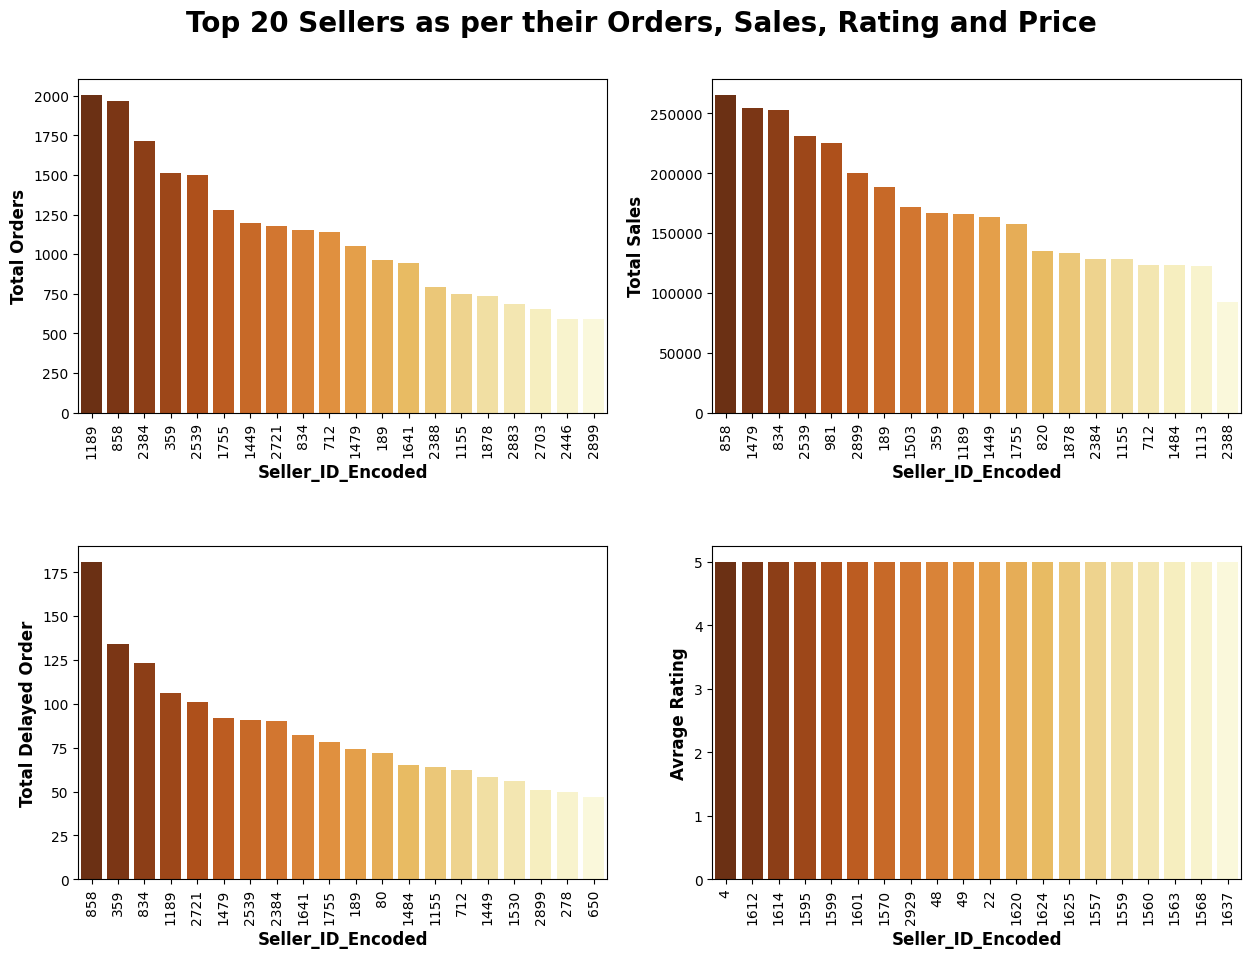

In [47]:
plt.figure(figsize=(15,10))
plt.suptitle("Top 20 Sellers as per their Orders, Sales, Rating and Price",fontsize=20,fontweight=750)

plt.subplot(2,2,1)
sns.barplot(data=seller.sort_values('total_orders',ascending=False).head(20),
            x='seller_id_en',y='total_orders',palette='YlOrBr_r',
            order=seller.sort_values('total_orders',ascending=False)['seller_id_en'].head(20))
plt.xlabel("Seller_ID_Encoded",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Total Orders",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)

plt.subplot(2,2,2)
sns.barplot(data=seller.sort_values('total_sales',ascending=False).head(20),x='seller_id_en',
            y='total_sales',palette='YlOrBr_r',
            order=seller.sort_values('total_sales',ascending=False)['seller_id_en'].head(20))
plt.xlabel("Seller_ID_Encoded",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Total Sales",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)

plt.subplot(2,2,3)
sns.barplot(data=seller.sort_values('total_delays',ascending=False).head(20),x='seller_id_en',
            y='total_delays',palette='YlOrBr_r',
            order=seller.sort_values('total_delays',ascending=False)['seller_id_en'].head(20))
plt.xlabel("Seller_ID_Encoded",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Total Delayed Order",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)

plt.subplot(2,2,4)
sns.barplot(data=seller.sort_values('rating',ascending=False).head(20),x='seller_id_en',
            y='rating',palette='YlOrBr_r',
            order=seller.sort_values('rating',ascending=False)['seller_id_en'].head(20))
plt.xlabel("Seller_ID_Encoded",fontdict={'fontsize':12,'fontweight':600})
plt.ylabel("Avrage Rating",fontdict={'fontsize':12,'fontweight':600})
plt.xticks(rotation=90)


plt.subplots_adjust(top=0.91,hspace=0.4)
plt.show()

► A few sellers (Encoded IDs 1189, 858, 894) dominate in both order count and total sales, showing a concentration of business among top performers.<br>► These same sellers also have the most delayed orders, suggesting operational overload rather than poor service.<br>► Average ratings remain high (≈ 4.5–5), implying that customers still value these sellers despite occasional delays, likely due to product reliability or communication quality.

In [48]:
Day_trnd=df.loc[df['order_status']=='delivered'].set_index('order_purchase_timestamp')
Day_trnd

,order_id,product_id,product_category_name_english,review_score,seller_id,seller_state,price,freight_value,order_status,customer_id,customer_type,customer_zip_code_prefix,geo_lat,geo_long,customer_state,cust_region,payment_type,payment_value,payment_range,shipping_limit_date,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delayed,delay_in_days,days_taken_seller_to_carrier,estimated_days_for_delivery_by_carrier,days_taken_by_carrier,seller_id_en
order_purchase_timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-10-03 09:44:00,3b697a20d9e427646d92567910af6d57,3ae08df6bcbfe23586dd431c40bddbb7,watches_gifts,4,522620dcb18a6b31cd7bdf73665113a9,PR,29.90,15.56,delivered,355077684019f7f60a031656bd7262b8,First-time,4106,-23.5828,-46.6362,SP,South_east,boleto,45.46,0-100,2016-10-21 16:27:00,2016-10-06 15:50:00,2016-10-23 14:02:00,2016-10-26 14:02:00,2016-10-27,0,-1,16,3,3,957
2016-10-03 16:56:00,be5bc2f0da14d8071e2d45451ad119d9,fd7fd78fd3cbc1b0a6370a7909c0a629,sports_leisure,4,f09b760d23495ac9a7e00d29b769007c,SP,21.90,17.19,delivered,7ec40b22510fdbea1b08921dd39e63d8,First-time,98280,-28.2953,-53.4996,RS,South,boleto,39.09,0-100,2016-10-21 16:33:00,2016-10-06 16:03:00,2016-10-21 16:33:00,2016-10-27 18:19:00,2016-11-07,0,-11,15,16,6,2789
2016-10-03 21:13:00,a41c8759fbe7aab36ea07e038b2d4465,b72b39418216e944bb34e35f4d3ea8c7,sports_leisure,3,45d33f715e24d15a6ccf5c17b3a23e3c,SP,36.49,17.24,delivered,6f989332712d3222b6571b1cf5b835ce,First-time,90040,-30.0431,-51.2114,RS,South,boleto,53.73,0-100,2016-10-21 16:18:00,2016-10-05 03:11:00,2016-10-25 11:57:00,2016-11-03 10:58:00,2016-11-29,0,-26,20,34,8,816
2016-10-03 22:06:00,d207cc272675637bfed0062edffd0818,107177bf61755f05c604fe57e02467d6,furniture_decor,1,cca3071e3e9bb7d12640c9fbe2301306,SP,119.90,13.56,delivered,b8cf418e97ae795672d326288dfab7a7,First-time,13185,-22.9044,-47.1755,SP,South_east,credit_card,133.46,100-200,2016-10-21 16:23:00,2016-10-04 10:28:00,2016-10-21 14:23:00,2016-10-31 11:07:00,2016-11-23,0,-23,17,32,9,2388
2016-10-03 22:31:00,cd3b8574c82b42fc8129f6d502690c3e,e2a1d45a73dc7f5a7f9236b043431b89,fashion_shoes,5,b499c00f28f4b7069ff6550af8c1348a,SP,29.99,10.96,delivered,7812fcebfc5e8065d31e1bb5f0017dae,First-time,12030,-23.0370,-45.5700,SP,South_east,credit_card,40.95,0-100,2016-10-08 10:34:00,2016-10-04 10:19:00,2016-10-08 10:34:00,2016-10-14 16:08:00,2016-11-23,0,-40,4,45,6,2083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-29 12:25:00,52018484704db3661b98ce838612b507,777798445efd625458a90c13f3b3e6e7,toys,1,5f2684dab12e59f83bef73ae57724e45,SP,63.90,9.20,delivered,e450a297a7bc6839ceb0cf1a2377fa02,First-time,5863,-23.6778,-46.7639,SP,South_east,credit_card,73.10,0-100,2018-08-31 12:35:00,2018-08-29 12:35:00,2018-08-29 13:38:00,2018-08-30 22:48:00,2018-09-03,0,-4,0,4,1,1129
2018-08-29 14:18:00,0b223d92c27432930dfe407c6aea3041,2b4472df15512a2825ae86fd9ae79335,kitchen_dining_laundry_garden_furniture,5,67bf6941ba2f1fa1d02c375766bc3e53,PR,209.00,46.48,delivered,e60df9449653a95af4549bbfcb18a6eb,First-time,80045,-25.4255,-49.2545,PR,South,credit_card,510.96,500-600,2018-08-31 14:30:00,2018-08-29 14:31:00,2018-08-29 15:29:00,2018-08-30 16:24:00,2018-09-04,0,-5,0,5,1,1218
2018-08-29 14:18:00,168626408cb32af0ffaf76711caae1dc,bdcf6a834e8faa30dac3886c7a58e92e,health_beauty,5,2a84855fd20af891be03bc5924d2b453,MG,45.90,15.39,delivered,6e353700bc7bcdf6ebc15d6de16d7002,First-time,38600,-17.2113,-46.8864,MG,South_east,voucher,61.29,0-100,2018-08-31 14:30:00,2018-08-29 14:30:00,2018-08-29 18:51:00,2018-08-30 16:52:00,2018-09-11,0,-12,0,12,0,488


In [49]:
monthly_orders=Day_trnd['order_id'].resample("M").count().reset_index()
monthly_orders.rename(columns={'order_purchase_timestamp':'Month_end','order_id':'total_orders'},inplace=True)

monthly_delays=Day_trnd['delayed'].resample("M").sum().reset_index()
monthly_delays.rename(columns={'order_purchase_timestamp':'Month_end','delayed':'total_delays'},inplace=True)

monthly_sales=Day_trnd['payment_value'].resample("M").sum().reset_index()
monthly_sales.rename(columns={'order_purchase_timestamp':'Month_end','payment_value':'total_sales'},inplace=True)

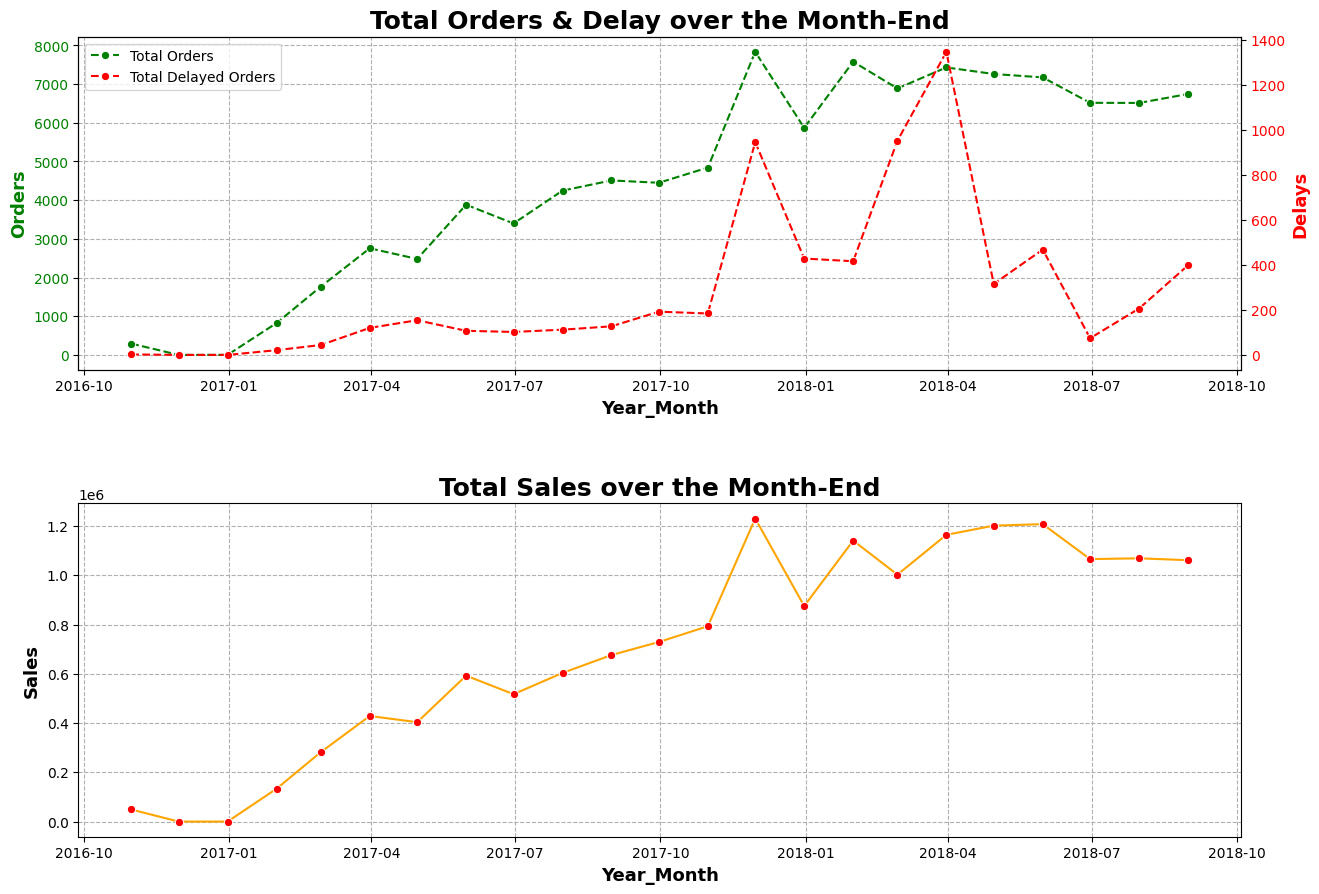

In [50]:
plt.figure(figsize=(15,10))

plt.subplot(2,1,1)
ax=plt.gca()
plt.title('Total Orders & Delay over the Month-End',fontdict={'fontsize':18,'fontweight':700},)
sns.lineplot(data=monthly_orders,x='Month_end',y='total_orders',color='green',
             linestyle='--',marker='o',label='Total Orders',ax=ax,legend=False)
plt.xlabel('Year_Month',fontdict={'fontsize':13,'fontweight':600})
plt.ylabel('Orders',fontdict={'fontsize':13,'fontweight':600},color='green')
plt.yticks(color='green')
plt.grid(True,linestyle='--')

ax2=ax.twinx()
sns.lineplot(data=monthly_delays,x='Month_end',y='total_delays',color='red',
             linestyle='--',marker='o',label='Total Delayed Orders',ax=ax2)
plt.xlabel('Year_Month',fontdict={'fontsize':13,'fontweight':600})
plt.ylabel('Delays',fontdict={'fontsize':13,'fontweight':600},color='red')
plt.yticks(color='red')

l1,la1=ax.get_legend_handles_labels()
l2,la2=ax2.get_legend_handles_labels()
plt.legend(l1+l2,la1+la2,loc='upper left')


plt.subplot(2,1,2)
plt.title('Total Sales over the Month-End',fontdict={'fontsize':18,'fontweight':700})
sns.lineplot(data=monthly_sales,x='Month_end',y='total_sales',color='orange',
             marker='o',markerfacecolor='red')
plt.xlabel('Year_Month',fontdict={'fontsize':13,'fontweight':600})
plt.ylabel('Sales',fontdict={'fontsize':13,'fontweight':600})
plt.grid(True,linestyle='--')


plt.subplots_adjust(top=0.91,hspace=0.4)
plt.show()

► Orders and sales show steady growth from 2016 to mid-2018, reflecting Olist’s rapid business expansion and customer adoption.<br>► Delay spikes in early 2018 (especially around April) indicate logistics strain as volume scaled faster than fulfillment capacity.<br>► Despite these fluctuations, sales remained resilient, suggesting that customer demand stayed strong even when delivery performance dipped.

## Hypothesis Testing

### Test 1: *Are review scores different for delayed vs. on-time deliveries?(T-test of Independence)*
### H₀: *The mean review score is the same for delayed and on-time orders.*<br>H₁: *They differ significantly.*

In [51]:
from scipy import stats

on_time_reviews = df.loc[df['delayed']==0 , 'review_score']
delayed_reviews = df.loc[df['delayed']==1 , 'review_score']

print(f'Average rating for Early/On-time delivery: {on_time_reviews.mean():0.5f}')
print(f'Average rating for Delayed delivery: {delayed_reviews.mean():0.5f}')
tstat, pvalue = stats.ttest_ind(on_time_reviews, delayed_reviews, equal_var=False, nan_policy='omit')
print("\nt-test Results:")
print(f't-statistic: {tstat:0.5f}')
print(f'p-value: {pvalue}\n')
if pvalue<0.05:
    print("Since pvalue is less than 0.05 hence, We reject H₀")
    print("means, there is significant difference between average review score of delayed and on-time orders")
else:
    print("Since pvalue is more than 0.05 hence, We failed to reject H₀")
    print("means, there is no difference between average review score of delayed and on-time orders")
print('-'*120)

Average rating for Early/On-time delivery: 4.25159
Average rating for Delayed delivery: 2.26382

t-test Results:
t-statistic: 101.99359
p-value: 0.0

Since pvalue is less than 0.05 hence, We reject H₀
means, there is significant difference between average review score of delayed and on-time orders
------------------------------------------------------------------------------------------------------------------------


### Test 2: *Does Payment Method Affect Delivery Delays?(Chi-Square Test of Independence)*
### H₀: *Payment type and delivery delay are independent.*<br>H₁: *Payment type and delivery delay are associated with each other.*

In [52]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['payment_type'], df['delayed'])

print("Contingency Table (Observed Frequencies):")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

expected_df = pd.DataFrame(expected, 
                           index=contingency.index, 
                           columns=contingency.columns)
print("\nExpected Frequencies (Under H₀):")
print(expected_df.round(0))

print("\nChi-square Test Results:")
print(f"Chi2 Statistic: {chi2:.5f}")
print(f"Degrees of Freedom:{dof}")
print(f"P-value: {p:.5f}\n")

if p<0.05:
    print("Since pvalue is less than 0.05 hence, We reject H₀")
    print("means, There is a statistically significant association between payment type and delivery delay.")
else:
    print("Since pvalue is more than 0.05 hence, We failed to reject H₀")
    print("means, No significant association between payment type and delivery delay.")
print('-'*120)

Contingency Table (Observed Frequencies):
delayed           0     1
payment_type             
boleto        18309  1388
credit_card   71981  4960
debit_card     1460    80
voucher        4809   285

Expected Frequencies (Under H₀):
delayed             0       1
payment_type                 
boleto        18417.0  1280.0
credit_card   71940.0  5001.0
debit_card     1440.0   100.0
voucher        4763.0   331.0

Chi-square Test Results:
Chi2 Statistic: 21.23441
Degrees of Freedom:3
P-value: 0.00009

Since pvalue is less than 0.05 hence, We reject H₀
means, There is a statistically significant association between payment type and delivery delay.
------------------------------------------------------------------------------------------------------------------------


### Test 3: *Does the average delivery delay differ significantly across customer states? (ANOVA Test)*
### H₀: *Average delay is the same across all customer states.*<br>H₁: *At least one state has a different average delay.*

In [53]:
from scipy.stats import f_oneway

df_anova = df[['customer_state', 'delay_in_days']]
days = []    
state_names = []

for state, d_days in df_anova.groupby('customer_state'):
    if len(d_days) > 5:                      
        days.append(d_days['delay_in_days'])
        state_names.append(state)

print(f"{len(days)} states included in ANOVA test.")

fstat, pval = f_oneway(*days)

print("\nOne-way ANOVA Test Results:")
print(f"F-statistic: {fstat:.4f}")
print(f"P-value: {pval:.6f}\n")

if pval < 0.05:
    print("Since pvalue is less than 0.05 hence, We reject H₀")
    print("means, There is a statistically significant difference in average delivery delay across customer states.")
else:
    print("Since pvalue is more than 0.05 hence, We failed to reject H₀")
    print("means, No significant difference in average delivery delay across customer states.")
print('-'*120)

27 states included in ANOVA test.

One-way ANOVA Test Results:
F-statistic: 60.0427
P-value: 0.000000

Since pvalue is less than 0.05 hence, We reject H₀
means, There is a statistically significant difference in average delivery delay across customer states.
------------------------------------------------------------------------------------------------------------------------


## Predictive Modelling 

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
import joblib

features = ['price', 'freight_value', 'payment_value']
cat_cols = ['payment_type', 'product_category_name_english', 'customer_state','seller_state']

x = df[features + cat_cols].copy()
y = df['delayed']

num_transform = StandardScaler()
cat_transform = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preproc = ColumnTransformer([
    ('num', num_transform, features),
    ('cat', cat_transform, cat_cols)
])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=15,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,   # since RandomOverSampler handles imbalance
    n_jobs=-1
)

pipe = Pipeline([
    ('preprocessor', preproc),
    ('oversample', RandomOverSampler(random_state=42)),
    ('model', xgb_model)
])

pipe.fit(x_train, y_train)

joblib.dump(pipe, "delay_prediction_model.pkl")
print("\n📂📂📂 Model is saved.")
print("-"*120)

pred = pipe.predict(x_test)
pred_proba = pipe.predict_proba(x_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, pred))
print(f"ROC-AUC : {roc_auc_score(y_test, pred_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, pred_proba):.4f}")
print(f"Train Score : {pipe.score(x_train, y_train):.4f}")
print(f"Test Score  : {pipe.score(x_test, y_test):.4f}")
print("_"*120)


📂📂📂 Model is saved.
------------------------------------------------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     24140
           1       0.14      0.42      0.21      1678

    accuracy                           0.79     25818
   macro avg       0.55      0.62      0.55     25818
weighted avg       0.90      0.79      0.84     25818

ROC-AUC : 0.6809
PR-AUC  : 0.1395
Train Score : 0.8506
Test Score  : 0.7937
________________________________________________________________________________________________________________________


## **Business Recommendations for OList**

### **1. Strengthen Carrier Performance**
- #### *Implement stricter SLAs and track on-time delivery KPIs for each carrier.*
- #### *Collaborate with high-performing logistics partners and penalize underperformers.*
- #### *Impact :- Reduce overall delivery delays by 30–40% within 3–6 months.*

### **2. Improve Delivery in High-Delay Regions (Amazonas & Maranhão)**
- #### *Establish regional hubs or collaborate with local couriers to shorten transit times.*
- #### *Prioritize faster delivery routes for high-delay zones.*
- #### *Impact :- Cut delay rates in these states by up to 50%, enhancing nationwide reliability.*

### **3. Enhance Customer Retention & Experience**
- #### *Launch loyalty rewards and send proactive delay notifications with compensation options.*
- #### *Focus on turning first-time buyers into repeat customers through better service.*
- #### *Impact :- Boost average review scores by +1 point and repeat purchase rate by 10–15%.*

### **4. Optimize Seller & Category Operations**
- #### *Support top sellers and improve logistics for high-demand categories like Bed & Bath and Health & Beauty.*
- #### *Introduce capacity planning to avoid seller overload during peak periods.*
- #### *Impact :- Reduce category-related delays by 20–25% and increase fulfillment efficiency.*

### **5. Leverage Predictive Analytics for Delay Prevention**
- #### *Deploy machine learning to predict delay risk at order placement and flag high-risk shipments.*
- #### *Use accurate data-driven delivery estimates at checkout to improve transparency.*
- #### *Impact :- Prevent up to 25% of potential delays before dispatch and strengthen customer trust.*
---

## **Below we can predict single order at a time**

In [ ]:
#here we can predict our orders can be delayed or not

price = float(input("enter price:"))
freight_value = float(input("enter freight_value:"))
payment_value = float(input("enter payment_value:"))
payment_type = str(input("enter payment_type:"))
product_category_name_english = str(input("enter product_category_name_english:"))
customer_state = str(input("enter customer_state:"))

new_data = pd.DataFrame({
    'price': [price],
    'freight_value': [freight_value],
    'payment_value': [payment_value],
    'payment_type': [payment_type],
    'product_category_name_english': [product_category_name_english],
    'customer_state': [customer_state]
})

# Load the pre-trained model
pipe = joblib.load("delay_prediction_model.pkl")

# Use the pipeline to make predictions
prediction = pipe.predict(new_data)

print(f"Prediction: {'likely to be Delayed' if prediction[0] == 1 else 'Likely to be On-Time or Early'}")